#**SEGMENTAZIONE DELLA CLIENTELA DI UN'AZIENDA DI SERVIZI FINANZIARI PER CAMPAGNE DI MARKETING MIRATE**

In questo notebook i clienti di FinTech Solution S.p.A. verranno segmentati, in base alle loro abitudini di utilizzo della carta di credito, attraverso la tecnica di apprendimento non supervisionato di Machine Learning: il Clustering.

Questo permetterà all'azienda di creare campagne di marketing mirate con offerte personalizzate per gruppi specifici di utenti, portando ad una maggiore fidelizzazione dei clienti.

Il processo verrà suddiviso in sezioni per facilitarne la lettura e la comprensione.

##**Preparazione all'analisi**

Importazione di librerie/moduli necessari. Settaggio parametri per le visualizzazioni.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
# Dimesione grafici di default (usata solo se non specificata nelle singole visualizzazioni)
plt.rcParams["figure.figsize"] = (10, 6)

sns.set_theme()

# Constante del seed per garantire riproducibilità dei risultati
RANDOM_SEED = 42

##**1. Analisi Esplorativa dei Dati (EDA)**

Caricamento del dataset ed esplorazione generale.

In [ ]:
df_raw = pd.read_csv("https://proai-datasets.s3.eu-west-3.amazonaws.com/credit_card_customers.csv")
df = df_raw.copy()
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [ ]:
df.shape

(8950, 18)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [ ]:
df.isnull().sum()

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [ ]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


##**2. Preprocessing dei Dati e Analisi Esplorativa Avanzata**

Rimozione feature CUST_ID in quanto non utile al clustering, gestione dei valori mancanti, correlazione tra variabili ed eventuali ridondanze, standardizzazione dei dati.



In [ ]:
# Rimozione CUST_ID (non utile)
df = df.drop("CUST_ID", axis=1)

In [ ]:
# Imputazione valori mancanti
df["MINIMUM_PAYMENTS"] = df["MINIMUM_PAYMENTS"].fillna(df["MINIMUM_PAYMENTS"].median())
df["CREDIT_LIMIT"] = df["CREDIT_LIMIT"].fillna(df["CREDIT_LIMIT"].median())

# Verifica che non ci siano più valori mancanti
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


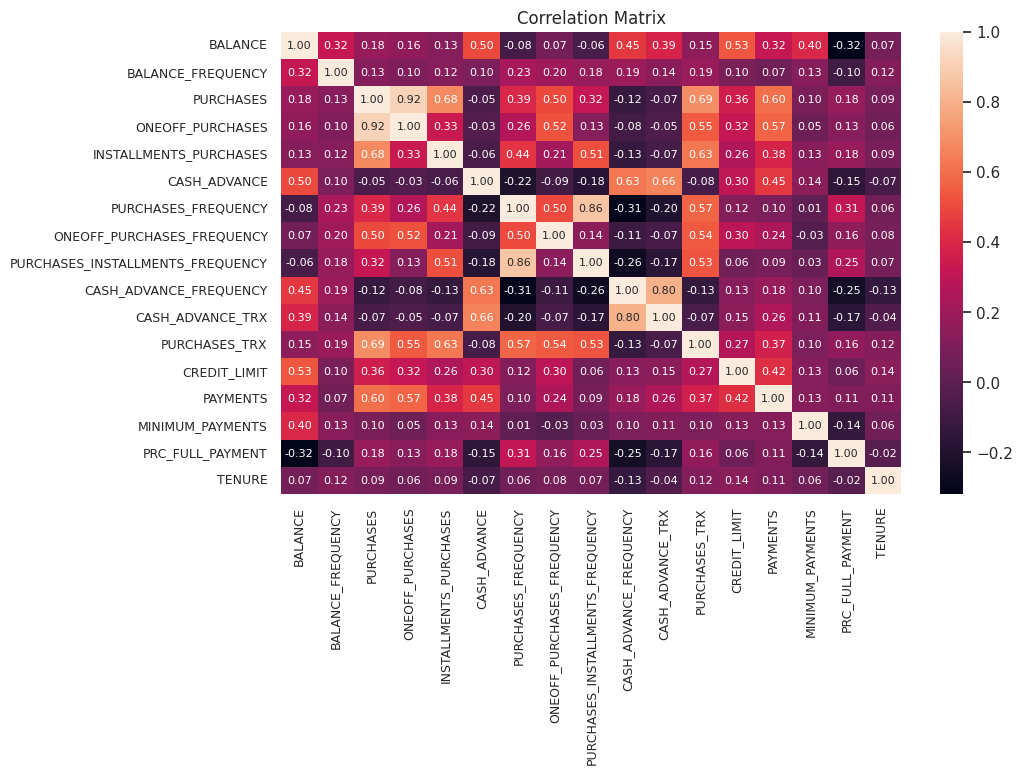

In [ ]:
# Correlazione tra le variabili
sns.heatmap(df.corr(),annot=True, annot_kws={"size":8}, fmt=".2f")
plt.title("Correlation Matrix")
plt.xticks(fontsize=9)
plt.yticks(fontsize=9)
plt.show()

**Commento**: La matrice di correlazione non evidenzia correlazioni elevate tra variabili che misurano la medesima dimensione concettuale tali da indicare ridondanze significative. Pertanto tutte le feature sono mantenute nel modello di clustering in quanto descrivono aspetti complementari del comportamento dei clienti.

In [ ]:
# Standardizzazione dei dati
ss = StandardScaler()
X = ss.fit_transform(df)

##**3. Segmentazione tramite Clustering**

Ricerca del numero ideale di cluster, addestramento del modello per la segmentazione con algoritmo k-means

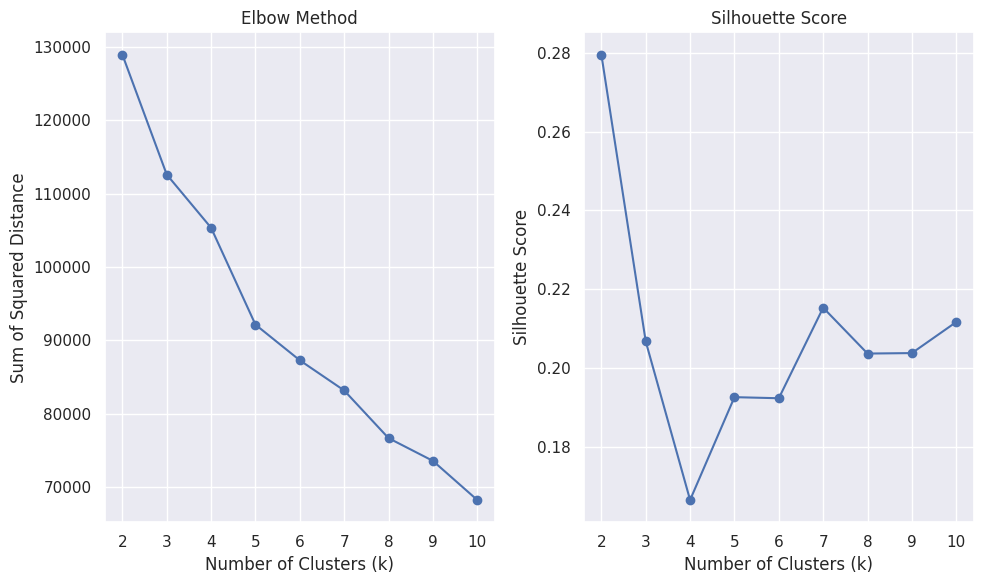

In [ ]:
# Elbow Method e silhouette score per definire il numero ideale di cluster
ssd = {}
silhouette = {}
k_range = range(2, 11)

for k in k_range:
  kmeans = KMeans(n_clusters=k, init="k-means++", random_state=RANDOM_SEED)
  kmeans.fit(X)
  ssd[k] = kmeans.inertia_

  sil_score = silhouette_score(X, kmeans.labels_)
  silhouette[k] = sil_score

# Visualizzazione su due grafici
plt.subplot(1, 2, 1)
plt.plot(list(ssd.keys()), list(ssd.values()), marker="o")
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Sum of Squared Distance")
plt.xticks(k_range)

plt.subplot(1, 2, 2)
plt.plot(list(silhouette.keys()), list(silhouette.values()), marker="o")
plt.title("Silhouette Score")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_range)

plt.tight_layout()
plt.show()

**Commento**: Sebbene la silhouette score mostri il valore massimo per k = 2, tale configurazione risulta troppo grossolana per una segmentazione efficace della clientela. Considerando l’elbow method e l’esigenza di ottenere cluster interpretabili e utili ai fini di marketing, viene selezionato **k = 5** come miglior compromesso tra qualità del clustering e significatività dei gruppi individuati.

In [ ]:
# Addestramento modello con k ideale = 5
kmeans = KMeans(n_clusters=5, init="k-means++", random_state=RANDOM_SEED)
kmeans.fit(X)
kmeans.inertia_

92131.46554452999

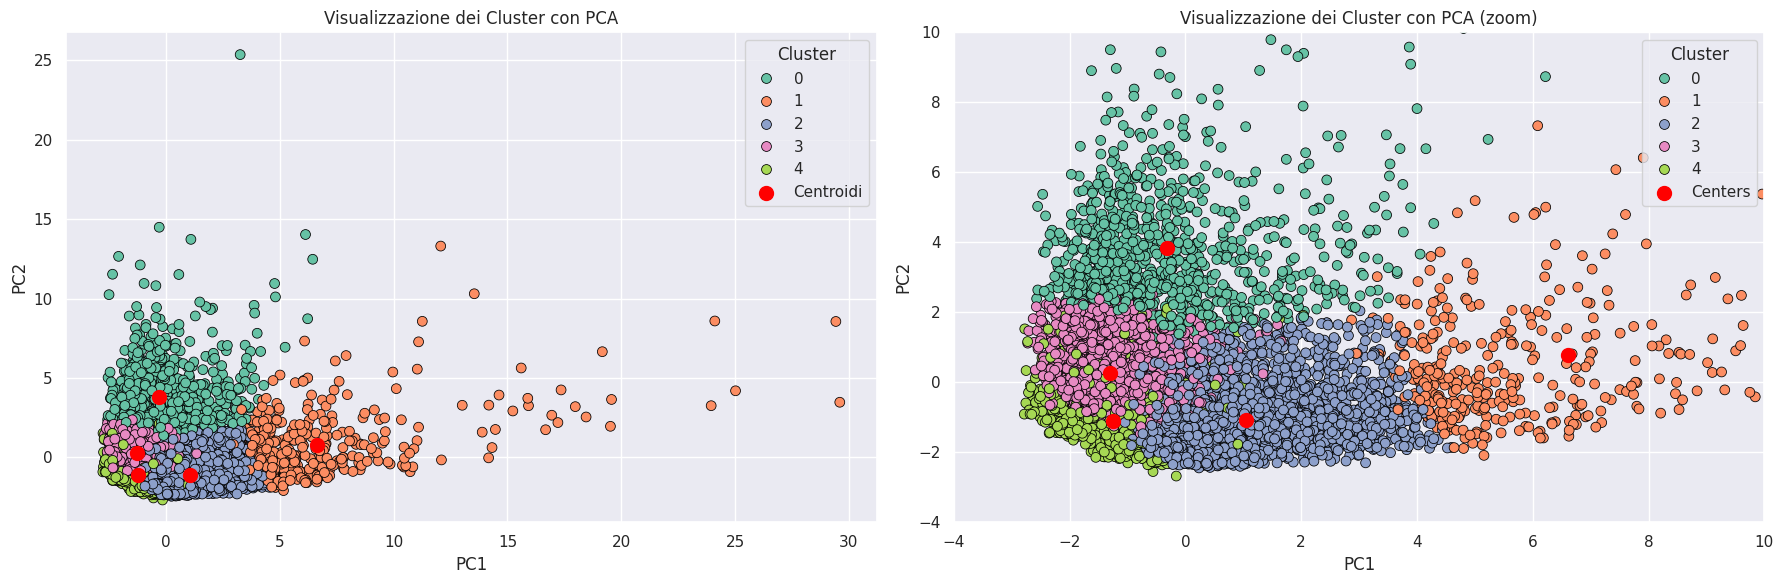

In [ ]:
# Visualizzazione con PCA
pca = PCA(n_components=2, random_state=RANDOM_SEED)
X_pca = pca.fit_transform(X)
centers_pca = pca.transform(kmeans.cluster_centers_)

plt.figure(figsize=(18, 6))

# Scatterplot completo
plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:,1], hue=kmeans.labels_, palette="Set2", edgecolors="black", s=50)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c="red", s=100, label="Centroidi")

plt.title("Visualizzazione dei Cluster con PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")

# Scatterplot con assi limitati
plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:,1], hue=kmeans.labels_, palette="Set2", edgecolors="black", s=50)
plt.scatter(centers_pca[:,0], centers_pca[:,1], c="red", s=100, label="Centers")

plt.xlim(-4, 10)
plt.ylim(-4, 10)

plt.title("Visualizzazione dei Cluster con PCA (zoom)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="Cluster")

plt.tight_layout()
plt.show()

**Commento**: Poiché il dataset è composto da un numero elevato di variabili, non è possibile rappresentare direttamente le osservazioni in uno scatterplot. Per questo è stata utilizzata la Principal Component Analysis (PCA) a scopo di visualizzazione, proiettando i dati nello spazio delle prime due componenti principali che catturano la maggior parte della variabilità presente.<br>
Questa rappresentazione permette di osservare la distribuzione delle osservazioni raggruppate con relativi centroidi dei cluster.

In [ ]:
# Aggiunta cluster di appartenenza al DataFrame
df["CLUSTER"] = kmeans.labels_
df.head(10)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CLUSTER
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12,3
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12,0
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,1666.670542,0.636364,1499.00,1499.00,0.00,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,312.343947,0.000000,12,3
4,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12,3
5,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.0,1400.057770,2407.246035,0.000000,12,2
6,627.260806,1.000000,7091.01,6402.63,688.38,0.000000,1.000000,1.000000,1.000000,0.000000,0,64,13500.0,6354.314328,198.065894,1.000000,12,1
7,1823.652743,1.000000,436.20,0.00,436.20,0.000000,1.000000,0.000000,1.000000,0.000000,0,12,2300.0,679.065082,532.033990,0.000000,12,2
8,1014.926473,1.000000,861.49,661.49,200.00,0.000000,0.333333,0.083333,0.250000,0.000000,0,5,7000.0,688.278568,311.963409,0.000000,12,3
9,152.225975,0.545455,1281.60,1281.60,0.00,0.000000,0.166667,0.166667,0.000000,0.000000,0,3,11000.0,1164.770591,100.302262,0.000000,12,4


In [ ]:
# Distribuzione delle osservazioni per cluster
df["CLUSTER"].value_counts().sort_index()

,count
CLUSTER,
0,987
1,395
2,3164
3,3047
4,1357


##**4. Interpretazione dei Cluster**

Confronto tra i cluster e analisi mirata per ogni cluster.

Nota: Le analisi sono effettuate considerando i valori medi.

In [ ]:
# Funzione per calcolare le medie per cluster
def cluster_mean(df, features):
  return df.groupby("CLUSTER")[features].mean().round(2)

# Ordinamento crescente dei cluster
cluster_order = sorted(df["CLUSTER"].unique())

In [ ]:
# Overview delle medie di ogni feature per ogni cluster
cluster_mean(df, df.columns)

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE,CLUSTER
CLUSTER,,,,,,,,,,,,,,,,,,
0,4903.43,0.97,553.10,348.46,204.74,4983.09,0.31,0.15,0.20,0.51,15.50,8.60,8062.62,3858.81,2071.36,0.04,11.41,0.0
1,3588.99,0.99,7815.73,5203.52,2613.73,661.79,0.94,0.74,0.79,0.07,2.11,90.35,9769.62,7409.10,1987.58,0.29,11.95,1.0
2,930.36,0.96,1299.71,633.17,666.74,226.75,0.90,0.31,0.72,0.04,0.83,23.03,4272.48,1388.75,645.17,0.26,11.61,2.0
3,1526.12,0.97,255.46,206.44,49.38,794.78,0.16,0.09,0.07,0.16,3.04,2.88,3244.23,958.64,804.54,0.02,11.51,3.0
4,111.26,0.38,335.22,199.44,136.00,325.75,0.28,0.07,0.20,0.04,0.79,4.28,3687.35,1076.94,176.59,0.23,11.27,4.0


###**4.1 Spese medie**

Analisi sulle abitudini di spesa in termini di:
- acquisti in unica soluzione (ONEOFF_PURCHASES)
- acquisti a rate (INSTALLMENTS_PURCHASES)

e confronto con saldo residuo (BALANCE)

In [ ]:
# Variabili da usare e calcolo delle medie
spending_features = ["BALANCE", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES", "PURCHASES"]
spending_mean = cluster_mean(df, spending_features)
spending_mean

,BALANCE,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,PURCHASES
CLUSTER,,,,
0,4903.43,348.46,204.74,553.10
1,3588.99,5203.52,2613.73,7815.73
2,930.36,633.17,666.74,1299.71
3,1526.12,206.44,49.38,255.46
4,111.26,199.44,136.00,335.22


Attenzione! I due grafici - Acquisti in Unica Soluzione e Acquisti a Rate - hanno scale diverse.
La scala del primo risulta doppia rispetto alla scala del secondo.


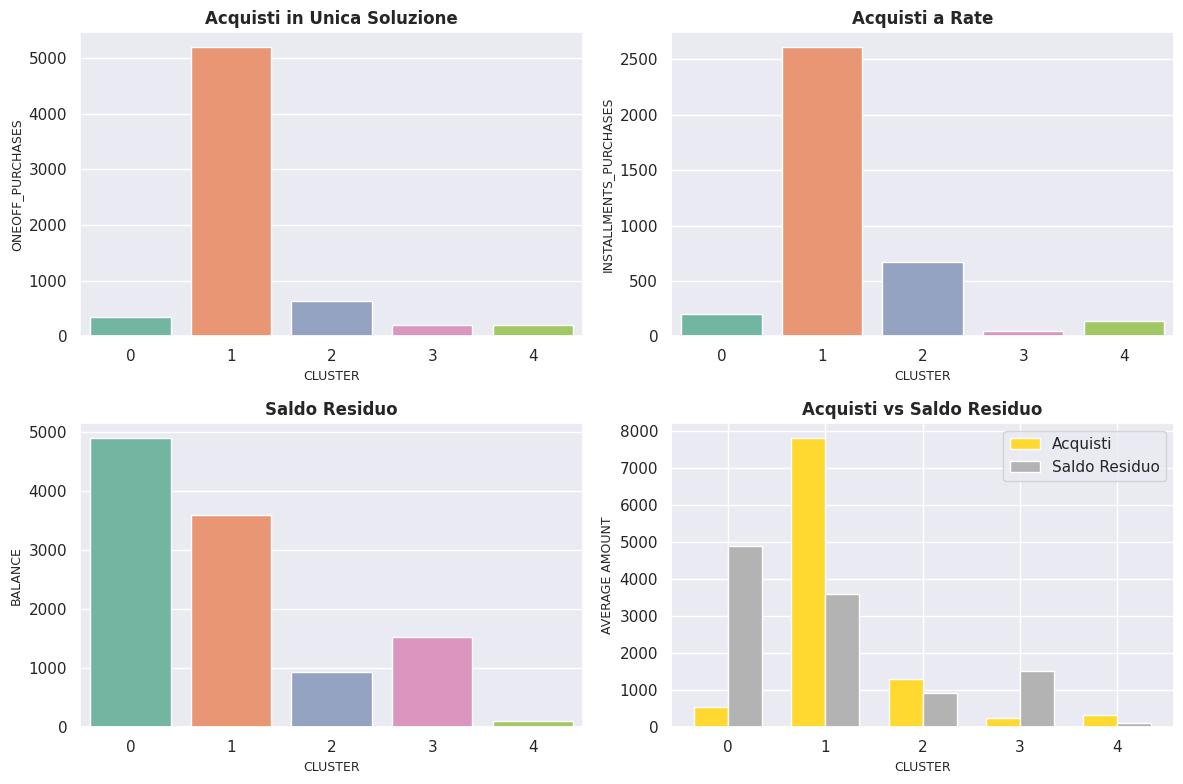

In [ ]:
# Nota utile
print("Attenzione! I due grafici - Acquisti in Unica Soluzione e Acquisti a Rate - hanno scale diverse.\n"+
      f"La scala del primo risulta doppia rispetto alla scala del secondo.")

# Creazione dei grafici
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

# Primo grafico
sns.barplot(data=df, x="CLUSTER", y="ONEOFF_PURCHASES", hue="CLUSTER",
            palette="Set2", errorbar=None, ax=axes[0])
axes[0].set_title("Acquisti in Unica Soluzione")

# Secondo grafico
sns.barplot(data=df, x="CLUSTER", y="INSTALLMENTS_PURCHASES", hue="CLUSTER",
            palette="Set2", errorbar=None, ax=axes[1])
axes[1].set_title("Acquisti a Rate")

# Terzo grafico
sns.barplot(data=df, x="CLUSTER", y="BALANCE", hue="CLUSTER", palette="Set2",
            errorbar=None, ax=axes[2])
axes[2].set_title("Saldo Residuo")

for ax in axes:
  ax.title.set_fontweight("bold")
  ax.xaxis.label.set_size(9)
  ax.yaxis.label.set_size(9)
  if ax.get_legend() is not None:
    ax.get_legend().remove()

# Quarto grafico
index = range(len(cluster_order))
width_bar = 0.35

axes[3].bar([i - width_bar/2 for i in index], spending_mean["PURCHASES"],
            width=width_bar, color=sns.color_palette("Set2")[5], label="Acquisti")
axes[3].bar([i + width_bar/2 for i in index], spending_mean["BALANCE"],
            width=width_bar, color=sns.color_palette("Set2")[7], label="Saldo Residuo")

axes[3].set_title("Acquisti vs Saldo Residuo", fontweight="bold")
axes[3].set_xticks(index)
axes[3].set_xticklabels(cluster_order)
axes[3].set_xlabel("CLUSTER")
axes[3].set_ylabel("AVERAGE AMOUNT")
axes[3].legend()

plt.tight_layout()
plt.show()

**Commento**

L’analisi delle spese medie evidenzia differenze tra i cluster:

Il **Cluster 0** presenta un bilancio medio molto elevato a fronte di un livello di acquisti relativamente contenuto, indicando una significativa esposizione residua non direttamente riconducibile alla spesa nel periodo osservato. La spesa risulta leggermente più concentrata sugli acquisti in unica soluzione, ma non vi è una differenza significativa tale da suggerire una prefenza.

Il **Cluster 1** si distingue per livelli di acquisto molto elevati, accompagnati da un bilancio medio inferiore rispetto alla spesa complessiva, suggerendo una maggiore capacità di rientro dal debito nonostante l’elevato utilizzo della carta. La spesa risulta doppiamente concentrata su acquisti in unica soluzione, suggerendo un utilizzo meno orientato alla rateizzazione.

Il **Cluster 2** mostra valori di acquisto e di bilancio che si discostano in misura contenuta, con una spesa complessiva relativamente bassa e un bilancio comunque elevato in rapporto agli acquisti effettuati. Le spese per acquisti in unica soluzione e acquisti rateali risultano molto equilibrate, non suggerendo una preferenza.

Il **Cluster 3** è caratterizzato da livelli di spesa molto bassi, a fronte di un bilancio medio elevato rispetto agli acquisti, suggerendo un'esposizione residua non associata a un utilizzo recente della carta. Gli acquisti presenti risultano più orientati alla soluzione unica, mentre la componente rateale è marginale.

Il **Cluster 4** presenta livelli di spesa molto bassi accompagnati da un bilancio esiguo, suggerendo un utilizzo complessivamente limitato della carta di credito e una ridotta esposizione residua. La spesa è marginale sia in unica soluzione sia in forma rateale, configurando un profilo di utilizzo minimo.

###**4.2 Abitudini di pagamento**

Analisi delle abitudini di pagamento in termini di:
- Pagamenti dell'importo minimo (MINIMUM_PAYMENTS)
- Percentuale dei pagamenti completi (PRC_FULL_PAYMENT)
- Importo totale dei pagamenti (PAYMENTS)

In [ ]:
# Variabili da usare e calcolo delle medie
payment_features = ["MINIMUM_PAYMENTS", "PRC_FULL_PAYMENT", "PAYMENTS"]
payment_mean = cluster_mean(df, payment_features)
payment_mean

,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,PAYMENTS
CLUSTER,,,
0,2071.36,0.04,3858.81
1,1987.58,0.29,7409.10
2,645.17,0.26,1388.75
3,804.54,0.02,958.64
4,176.59,0.23,1076.94


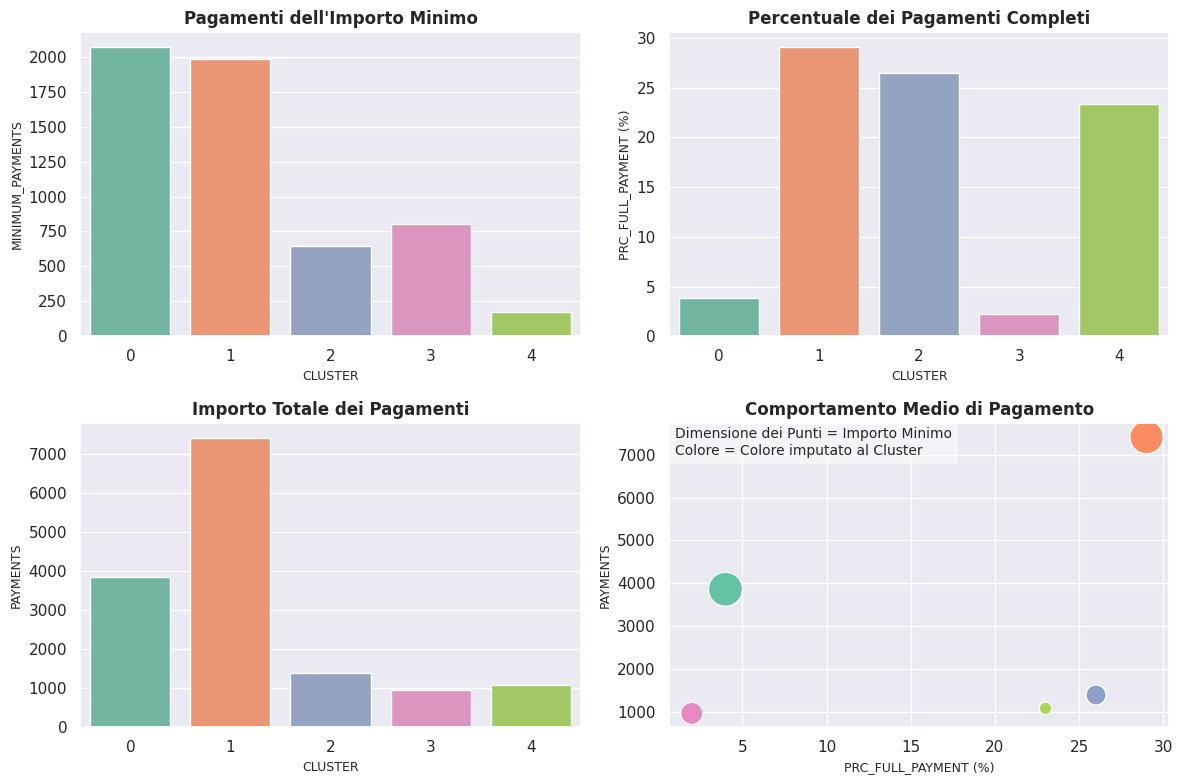

In [ ]:
# Creazione dei grafici
fig, axes = plt.subplots(2, 2, figsize=(12,8))
axes = axes.flatten()


# Primo grafico
sns.barplot(data=df, x="CLUSTER", y="MINIMUM_PAYMENTS", hue="CLUSTER", palette="Set2",
            errorbar=None, ax=axes[0])

axes[0].set_title("Pagamenti dell'Importo Minimo")


# Secondo grafico
sns.barplot(data=df, x="CLUSTER", y=df["PRC_FULL_PAYMENT"]*100, hue="CLUSTER", palette="Set2",
            errorbar=None, ax=axes[1])

axes[1].set_title("Percentuale dei Pagamenti Completi")
axes[1].set_ylabel("PRC_FULL_PAYMENT (%)")


# Terzo grafico
sns.barplot(data=df, x="CLUSTER", y="PAYMENTS", hue="CLUSTER", palette="Set2",
            errorbar=None, ax=axes[2])

axes[2].set_title("Importo Totale dei Pagamenti")


# Quarto grafico
sns.scatterplot(data=payment_mean, x=payment_mean["PRC_FULL_PAYMENT"]*100, y="PAYMENTS",
                hue="CLUSTER", size="MINIMUM_PAYMENTS", sizes=(80, 600), palette="Set2", ax=axes[3])

axes[3].set_title("Comportamento Medio di Pagamento")
axes[3].set_xlabel("PRC_FULL_PAYMENT (%)")
axes[3].set_ylabel("PAYMENTS")
axes[3].text(1, 7000, "Dimensione dei Punti = Importo Minimo\nColore = Colore imputato al Cluster",
             size=10, bbox=dict(boxstyle="Square, pad=0.3", lw=2, fc="white", alpha=0.5))


for ax in axes:
  ax.title.set_fontweight("bold")
  ax.xaxis.label.set_size(9)
  ax.yaxis.label.set_size(9)
  if ax.get_legend() is not None:
    ax.get_legend().remove()



plt.tight_layout()
plt.show()

**Commento**

Nel complesso, i cluster mostrano comportamenti di pagamento eterogenei:

I clienti del **Cluster 0** effettuano pagamenti di entità rilevante rispetto agli altri Cluster, ma non ai livelli del Cluster 1. Il comportamento è caratterizzato da un forte ricorso al pagamento minimo e da una bassa frequenza di saldo completo, indicando una tendenza a mantenere il debito nel tempo piuttosto che a chiuderlo rapidamente.

Il **Cluster 1** è caratterizzato da un comportamento di pagamento intenso e attivo: i clienti pagano importi elevati e saldano frequentemente il debito per intero, pur utilizzando anche il pagamento minimo. È il cluster con la maggiore capacità e regolarità di rientro.

I clienti del **Cluster 2** mostrano un comportamento più equilibrato: i pagamenti totali non sono particolarmente elevati, ma la frequenza di saldo completo è alta, indicando una buona gestione del debito con minore ricorso al pagamento minimo.

Il **Cluster 3** raccoglie clienti con volumi di pagamento ridotti e scarsa propensione a saldare completamente il debito. Anche l’importo dei pagamenti minimi non è elevato, suggerendo una gestione più passiva o limitata dei rientri.

I clienti del **Cluster 4** effettuano pagamenti complessivamente contenuti, con un ricorso molto limitato al pagamento minimo. Nonstante gli importi bassi, mostrano una propensione al saldo completo del debito, indicando un utilizzo moderato della carta di credito e una gestione prudente dell'esposizione.

###**4.3 Frequenza di utilizzo della carta**

Analisi delle abitudini di utilizzo della carta in termini di:
- Frequenza di utilizzo per gli acquisti (PURCHASES_FREQUENCY)
- Frequenza di utilizzo per anticipo di contanti (CASH_ADVANCE_FREQUENCY)

**Nota**: nei grafici le frequenze sono mostrate in %, ma non costituiscono una ripartizione percentuale dell'uso complessivo della carta. Indicano solo la frequenza con cui una specifica operazione è stata effettuata, indipendentemente da altre modalità di utilizzo.

In [ ]:
# Variabili da usare e calcolo delle medie
freq_features = ["PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY"]
freq_mean = cluster_mean(df, freq_features)
freq_mean

,PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY
CLUSTER,,
0,0.31,0.51
1,0.94,0.07
2,0.90,0.04
3,0.16,0.16
4,0.28,0.04


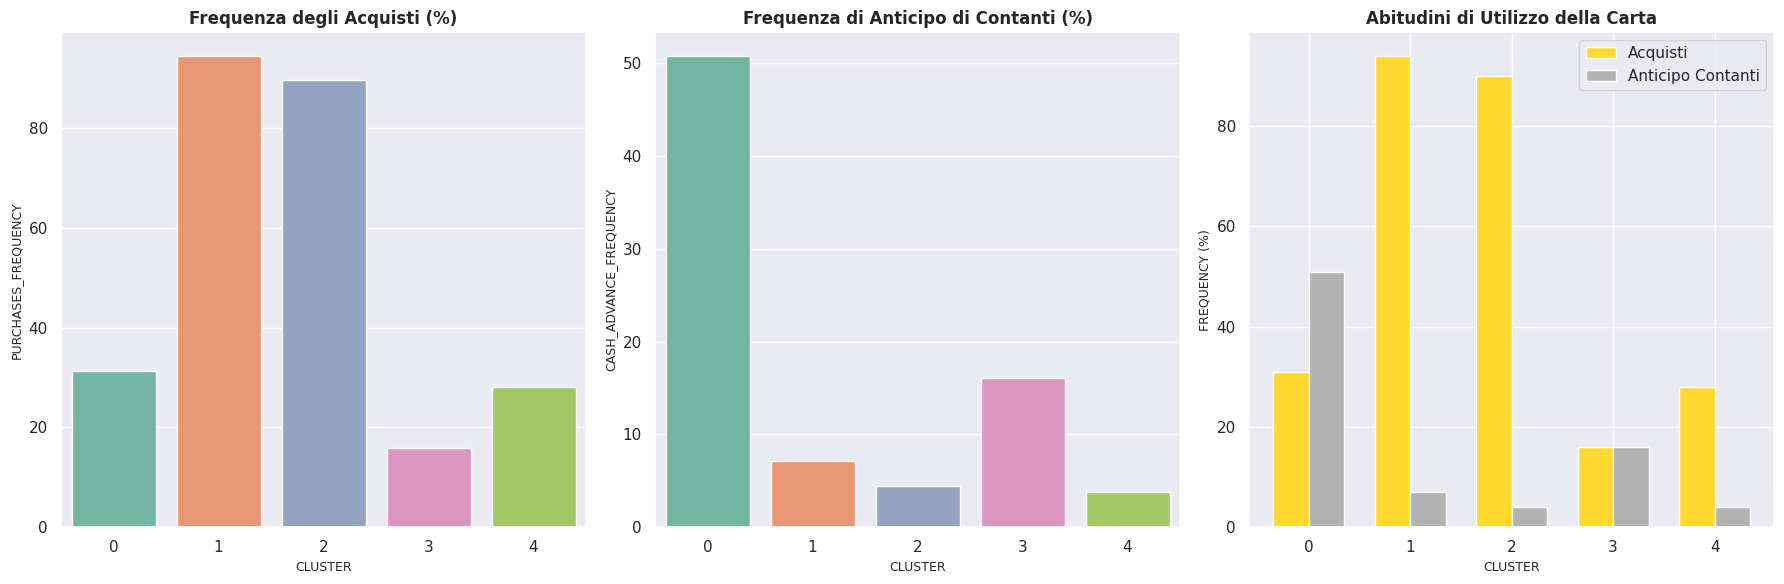

In [ ]:
# Creazione dei grafici
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Primo grafico
sns.barplot(data=df, x="CLUSTER", y=df["PURCHASES_FREQUENCY"]*100, hue="CLUSTER", palette="Set2",
            errorbar=None, ax=axes[0])

axes[0].set_title("Frequenza degli Acquisti (%)")

# Secondo grafico
sns.barplot(data=df, x="CLUSTER", y=df["CASH_ADVANCE_FREQUENCY"]*100, hue="CLUSTER", palette="Set2",
            errorbar=None, ax=axes[1])

axes[1].set_title("Frequenza di Anticipo di Contanti (%)")


for ax in axes:
  ax.title.set_fontweight("bold")
  ax.xaxis.label.set_size(9)
  ax.yaxis.label.set_size(9)
  if ax.get_legend() is not None:
    ax.get_legend().remove()

# Terzo grafico
index = range(len(cluster_order))
width_bar = 0.35

axes[2].bar([i - width_bar/2 for i in index], freq_mean["PURCHASES_FREQUENCY"]*100,
            width=width_bar, color=sns.color_palette("Set2")[5], label="Acquisti")
axes[2].bar([i + width_bar/2 for i in index], freq_mean["CASH_ADVANCE_FREQUENCY"]*100,
            width=width_bar, color=sns.color_palette("Set2")[7], label="Anticipo Contanti")

axes[2].set_title("Abitudini di Utilizzo della Carta", fontweight="bold")
axes[2].set_xticks(index)
axes[2].set_xticklabels(cluster_order)
axes[2].set_xlabel("CLUSTER")
axes[2].set_ylabel("FREQUENCY (%)")
axes[2].legend()


plt.tight_layout()
plt.show()

**Commento**

Nel complesso, l'analisi mostra modalità di utilizzo della carta differenti tra i cluster:

Il **Cluster 0** mostra una frequenza di utilizzo moderata per gli acquisti, accompagnata da una frequenza più elevata di anticipo di contante.<br>
Questo indica un utilizzo della carta meno orientato agli acquisti e più focalizzato sull'ottenimento di liquidità.

I **Cluster 1** e **2** sono cartterizzati da una frequenza di acquisti molto elevata e da una frequenza di anticipo di contanti molto bassa.<br>
Questo indica un utilizzo della carta quasi esclusivamente per gli acquisti, con scarso ricorso a forme di liquidità immediata.

Il **Cluster 3** presenta una frequenza di utilizzo bassa e molto bilanciata tra acquisti e anticipo di contanti.<br>
Questo indica un utilizzo sporadico della carta, senza una preferenza prevalente tra le due modalità.

Il **Cluster 4** presenta una frequenza di acquisti moderata e una frequenza di anticipo di contanti molto contenuta.<br>
Questo indica un utilizzo della carta moderato più prevalente per per gli acquisti, con scarso ricorso all'anticipo di liquidità.

###**4.4 Sintesi**
Sintesi generale e confronto relativo tra i cluster, descrizione completa di ogni cluster.

In [ ]:
# Variabili da usare e calcolo delle medie
profile_features = ["BALANCE", "PURCHASES", "PAYMENTS", "MINIMUM_PAYMENTS", "PRC_FULL_PAYMENT", "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY"]
profile_mean = cluster_mean(df, profile_features)

prc_cols = ["PRC_FULL_PAYMENT", "PURCHASES_FREQUENCY", "CASH_ADVANCE_FREQUENCY"]
profile_mean[prc_cols] = profile_mean[prc_cols]*100

cols_label = {"BALANCE": "Saldo Residuo (Importo)",
              "PURCHASES": "Acquisti (Importo)",
              "PAYMENTS": "Pagamenti (Importo)",
              "MINIMUM_PAYMENTS": "Pagamenti Minimi (Importo)",
              "PRC_FULL_PAYMENT": "Pagamenti Completi (%)",
              "PURCHASES_FREQUENCY": "Frequenza Acquisti (%)",
              "CASH_ADVANCE_FREQUENCY": "Frequenza Anticipo Contanti (%)"}

profile_mean = profile_mean.rename(columns=cols_label)

profile_mean

,Saldo Residuo (Importo),Acquisti (Importo),Pagamenti (Importo),Pagamenti Minimi (Importo),Pagamenti Completi (%),Frequenza Acquisti (%),Frequenza Anticipo Contanti (%)
CLUSTER,,,,,,,
0,4903.43,553.10,3858.81,2071.36,4.0,31.0,51.0
1,3588.99,7815.73,7409.10,1987.58,29.0,94.0,7.0
2,930.36,1299.71,1388.75,645.17,26.0,90.0,4.0
3,1526.12,255.46,958.64,804.54,2.0,16.0,16.0
4,111.26,335.22,1076.94,176.59,23.0,28.0,4.0


Nota: tutti i valori sono stati normalizzati su scala 10-100 per consentire un confronto relativo
del comportamento tipico dei Cluster. Quindi i valori non rappresentano importi o percentiuali reali.


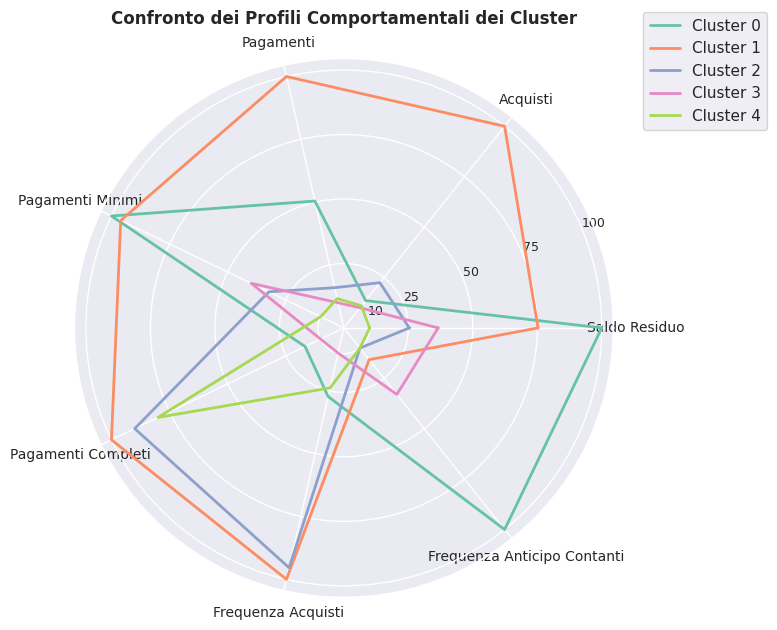

In [ ]:
# Nota esplicativa
print("Nota: tutti i valori sono stati normalizzati su scala 10-100 per consentire un confronto relativo\ndel comportamento tipico dei Cluster. "+
      f"Quindi i valori non rappresentano importi o percentiuali reali.")

# Creazione grafico radar per sintesi di confronto (valori normalizzati 10-100)
profile_norm = 10+(profile_mean - profile_mean.min()) / (profile_mean.max() - profile_mean.min())*90

# Setup radar e figura
labels = profile_norm.columns.str.replace(" (Importo)", "", regex=False).str.replace(" (%)", "", regex=False).tolist()
num_features = len(labels)
angles = np.linspace(0, 2*np.pi, num_features, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

colors = sns.color_palette("Set2", n_colors=len(cluster_order))

for i, cluster in enumerate(cluster_order):
  values = profile_norm.loc[cluster].tolist()
  values += values[:1]

  ax.plot(angles, values, linewidth=2, color=colors[i], label=f"Cluster {cluster}")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=10)
ax.set_yticks([10, 25, 50, 75, 100])
ax.set_yticklabels(["10", "25", "50", "75", "100"], fontsize=9)

ax.set_title("Confronto dei Profili Comportamentali dei Cluster", fontweight="bold", pad=25)
ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

plt.show()

###**Profili dei Cluster**

**Cluster 0**

Punti chiave:
- Saldo residuo molto elevato rispetto al livello di spesa
- Forte ricorso a pagamenti minimi, con pagamenti completi quasi assenti
- Pagamenti totali abbastanza alti in valore assoluto, ma insufficienti a ridurre il debito
- Uso molto frequente dell'anticipo in contanti
- Acquisti leggermente più tendenti alla soluzione unica rispetto alla soluzione rateale

Descrizione generale:<br>
Il cluster 0 rappresenta clienti con una gestione del credito fortemente sbilanciata. Nonostante effettuino pagamenti, questi avvengono per lo più al minimo, risultando poco efficaci nel ridurre un saldo residuo molto elevato. L'uso intensivo dell'anticipo in contanti suggerisce una frequente esigenza di liquidità. Sul fronte degli acquisti emerge una leggera preferenza all'utilizzo della soluzione unica, ma con una differenza minima rispetto agli acquisti rateali.

**Cluster 1**

Punti chiave:
- Saldo residuo abbastanza alto ma coerente con il volume di spesa
- Pagamenti elevati, con tendenza significativa sia a completare i pagamenti sia a ricorrere a pagamenti minimi
- Uso marginale dell'anticipo in contanti
- Acquisti molto elevati e frequenti, con preferenza ad acquisti in un'unica soluzione

Descrizione generale:<br>
Il cluster 1 identifica clienti altamente attivi, che utilizzano la carta soprattutto come strumento di pagamento per acquisti che non come fonte di liquidità. L'elevato volume di spesa è accompagnato da una buona capacità di rimborso, con una percentuale rilevante di saldi completi. La preferenza per gli acquisti in un'unica soluzione indica una maggiore solidità finanziaria e una gestione più consapevole del credito, pur in presenza di importi complessivamente alti.

**Cluster 2**

Punti chiave:
- Saldo residuo contenuto
- Pagamenti in linea con gli acquisti e buona incidenza di pagamenti completi
- Uso quasi assente degli anticipi di contanti
- Acquisti molto frequenti con importi molto moderati
- Equilibrio tra acquisti in un'unica soluzione e acquisti rateali

Descrizione generale:<br>
Il cluster 2 rappresenta clienti con un utilizzo regolare ed equilibrato della carta. La spesa è controllata e il comportamento di pagamento mostra buona propensione a chiudere il debito, mantenendo il saldo residuo su livelli bassi. L'assenza quasi totale di anticipo di contanti e la distribuzione equilibrata tra le modalità di acquisto indicano un profilo stabile, orientato ad un uso funzionale e pianificato della carta.

**Cluster 3**

Punti chiave:
- Saldo residuo elevato rispetto alla spesa
- Pagamenti bassi, prevalentemente minimi, con tendenza quasi nulla a completare i pagamenti
- Frequenze di acquisti e di anticipi in contanti basse, in egual misura
- Prevalenza di acquisti in un'unica soluzione e di importi ridotti

Descrizione generale:<br>
Il cluster 3 descrive clienti con bassa operatività in termini acquisti, ma con una posizione debitoria significativa rispetto alla spesa corrente. Il rimborso avviene quasi esclusivamente tramite pagamenti minimi, senza una reale riduzione del debito. Per quanto riguarda le modalità di acquisto, la prevalenza ricade sugli acquisti in un'unica soluzione, suggerendo una criticità del profilo non legata alla rateizzazione degli acquisti, ma alla gestione del debito residuo.

**Cluster 4**

Punti chiave:
- Saldo residuo molto contenuto
- Pagamenti coerenti con la spesa e molto tendenti al completamento
- Frequenza quasi nulla dell'anticipo di contanti
- Acquisti molto bassi con preferenza alla soluzione unica

Descrizione generale:<br>
Il cluster 4 identifica clienti prudenti e poco intensivi, che utilizzano la carta in modo limitato e mantengono un elevato controllo del debito. Il saldo residuo è basso e il comportamento di pagamento mostra una buona tendenza a saldare quanto dovuto. La preferenza per gli acquisti in un'unica soluzione e il ricorso esiguo all'anticipo di contante delineano un profilo orientato alla stabilità e alla gestione cauta del credito.

##**5. Sviluppo di Strategie di Marketing**

Sulla base dei profili comportamentali individuati, è possibile ipotizzare alcune strategie di marketing mitare, coerenti con le caratteristiche osservate nei diversi cluster.

**Cluster 0**

Obiettivo:<br>
Supportare una riduzione graduale dell'esposizione debitoria e migliorare la gestione del rimborso.

Possibili azioni:
- Comunicazioni informative o di educazione finanziaria sulla gestione del saldo e dei pagamenti
- Proposte di strumenti di supporto al rientro (es. reminder, simmulazioni di piani di rimborso)
- Limitazione o monitoraggio dell'uso dell'anticipo di contanti

Motivazione:<br>
Il cluster presenta un saldo residuo molto elevato, un uso frequente dei pagamenti minimi e una forte dipendenza dell'anticipo in contanti, con pagamenti completi quasi assenti. Risulta quindi necessario contenere il rischio e favorire una gestione più sostenibile del credito.

**Cluster 1**

Obiettivo:<br>
Valorizzare e fidelizzare questi clienti ad alto valore, incentivando l'uso della carta per gli acquisti.

Possibili azioni:
- Programmi di fidelizzazione legati al volume di spesa
- Incentivi o premi per l'utilizzo continuativo della carta
- Offerte personalizzare su categorie di acquisto frequenti

Motivazione:<br>
Il cluster mostra acquisti molto elevati e frequenti, con una buona capacità di rimborso e un uso minimo dell'anticipo di contanti. Si tratta di clienti attivi e strutturati, per i quali ha senso puntare su leve di fidelizzazione e valorizzazione.

**Cluster 2**

Obiettivo:<br>
Rafforzare l'utilizzo della carta mantenendo un equilibrio virtuoso rea spesa e rimborso.

Possibili azioni:
- Incentivi leggeri all'aumento della spesa (es. promozioni mirate)
- Comunicazioni orientate alla continuità di utilizzo
- Programmmi di fidelizzazione

Motivazione:<br>
Il cluster presenta un uso regolare della carta, seppur con spese minime, un saldo residuo contenuto e una buona percentuale di pagamenti completi, con quasi totale assenza di anticipi di contanti. Le strategie possono mirare a stimolare il valore del cliente, senza alterare un comportamento già sano ed equilibrato.

**Cluster 3**

Obiettivo:<br>
Mantenere il cliente attivo riducendo il rischio di accumulo del debito e favorendo una gestione più equilibrata del rimborso.

Possibili azioni:
- Comunicazioni informative o di educazione finanziaria sulla gestione del saldo e dei pagamenti
- Proposte di strumenti di supporto al rientro (es. reminder, simmulazioni di piani di rimborso)
- Incentivi al pagamento oltre il minimo

Motivazione:<br>
Il cluster presenta volumi di acquisto contenuti a fronte di un saldo residuo ancora significativo. Il comportamento di rimborso è fortemente orientato ai pagamenti minimi, mentre i pagamenti completi sono quasi assenti. Risulta necessario puntare a migliorare la qualità del rimborso, più che a stimolare la spesa.

**Cluster 4**

Obiettivo:<br>
Mantenere il profilo virtuoso e incentivare un utilizzo più frequente della carta.

Possibili azioni:
- Promozioni per stimolare l'uso della carta
- Comunicazioni orientate ai vantaggi dell'utilizzo della carta
- Valorizzazione del comportamento virtuoso (es. messaggi di riconoscimento, badge)

Motivazione:<br>
Il cluster mostra bassi livelli di spesa, saldo residuo molto contenuto, una discreta propensione ai pagamenti completi e un bassissimo uso dell'anticipo di contanti. Si tratta di clienti prudenti, per i quali ha senso puntare su azioni conservative rafforzino la fiducia e la semplicità d'uso della carta.